<a href="https://colab.research.google.com/github/nielitropar/computer-vision/blob/main/Face_Recognition_Modue_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Face Recognition: Multi-Person Attendance System

## Features

- Google Colab compatible
- Webcam image capture
- Multiple image uploads
- Multi-person dataset creation
- Automatic face encoding
- Multi-face attendance recognition
- Confidence score display
- Attendance CSV export
- Attendance duplicate prevention
- Clean beginner-friendly structure

This notebook builds a practical AI attendance system directly in Google Colab.


## Install Required Libraries

In [ ]:
!pip install -q face_recognition opencv-python pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Import Libraries

In [ ]:
import cv2
import os
import csv
import time
import numpy as np
import pandas as pd
import face_recognition
import matplotlib.pyplot as plt

from pathlib import Path
from google.colab import files
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

## Webcam Utility Function

In [ ]:
def take_photo(filename='photo.jpg', quality=0.9):

    js = '''
    async function takePhoto(quality) {

      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;

      await video.play();

      google.colab.output.setIframeHeight(
          document.documentElement.scrollHeight, true
      );

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getVideoTracks()[0].stop();

      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    '''

    display(Javascript(js))

    data = eval_js(f'takePhoto({quality})')

    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


# Create Dataset Folder


In [ ]:
DATASET_DIR = Path("face_attendance_dataset")
DATASET_DIR.mkdir(exist_ok=True)

print("Dataset folder created.")

Dataset folder created.



# Add Multiple Persons to Dataset

For each person you can:

- Upload multiple images
OR
- Capture multiple webcam photos


**Note:** First time when colab will try to access webcam it will ask for permession accpect (allow) it and run the cell again

In [ ]:
num_people = int(input("How many people do you want to add? "))

for person_index in range(num_people):

    print("\n==============================")
    print(f"Adding Person {person_index + 1}")
    print("==============================")

    # PERSON NAME

    person_name = input(
        "Enter person name: "
    ).strip()

    person_dir = DATASET_DIR / person_name
    person_dir.mkdir(exist_ok=True)

    # ASK INPUT METHOD FOR EACH PERSON

    print("\nChoose how you want to add images")
    print("1 = Upload Images Manually")
    print("2 = Take Photos using Webcam")

    choice = input(
        "\nEnter choice (1 or 2): "
    ).strip()

    # OPTION 1: MANUAL IMAGE UPLOAD

    if choice == "1":

        print("\nUpload multiple images for", person_name)

        uploaded = files.upload()

        for file_name in uploaded.keys():

            source_path = file_name

            destination_path = (
                person_dir / file_name
            )

            os.rename(
                source_path,
                destination_path
            )

            print(
                f"Saved: {destination_path}"
            )

    # OPTION 2: WEBCAM CAPTURE

    elif choice == "2":

        num_images = int(
            input(
                "\nHow many webcam photos to capture? "
            )
        )

        for i in range(num_images):

            filename = (
                f"{person_name}_{i+1}.jpg"
            )

            print(
                f"\nCapturing Image {i+1}"
            )

            photo_path = take_photo(filename)

            destination_path = (
                person_dir / filename
            )

            os.rename(
                photo_path,
                destination_path
            )

            print(
                f"Saved: {destination_path}"
            )

    # INVALID OPTION

    else:

        print("\nInvalid Choice")
        print("Skipping this person...")

How many people do you want to add? 3

Adding Person 1
Enter person name: Lovnish Verma

Choose how you want to add images
1 = Upload Images Manually
2 = Take Photos using Webcam

Enter choice (1 or 2): 2

How many webcam photos to capture? 5

Capturing Image 1


<IPython.core.display.Javascript object>

Saved: face_attendance_dataset/Lovnish Verma/Lovnish Verma_1.jpg

Capturing Image 2


<IPython.core.display.Javascript object>

Saved: face_attendance_dataset/Lovnish Verma/Lovnish Verma_2.jpg

Capturing Image 3


...

Saved: face_attendance_dataset/Lovnish Verma/Lovnish Verma_4.jpg

Capturing Image 5


<IPython.core.display.Javascript object>

Saved: face_attendance_dataset/Lovnish Verma/Lovnish Verma_5.jpg

Adding Person 2
Enter person name: Dr. Sarwan Singh

Choose how you want to add images
1 = Upload Images Manually
2 = Take Photos using Webcam

Enter choice (1 or 2): 1

Upload multiple images for Dr. Sarwan Singh


Saving sarwan_sir_3.jpeg to sarwan_sir_3.jpeg
Saving sarwan_sir_2.jpeg to sarwan_sir_2.jpeg
Saving sarwan_sir_1.jpeg to sarwan_sir_1.jpeg
Saved: face_attendance_dataset/Dr. Sarwan Singh/sarwan_sir_3.jpeg
Saved: face_attendance_dataset/Dr. Sarwan Singh/sarwan_sir_2.jpeg
Saved: face_attendance_dataset/Dr. Sarwan Singh/sarwan_sir_1.jpeg

Adding Person 3
Enter person name: Narender Modi G

Choose how you want to add images
1 = Upload Images Manually
2 = Take Photos using Webcam

Enter choice (1 or 2): 1

Upload multiple images for Narender Modi G


Saving modig3.jpg to modig3.jpg
Saving modig2.jpg to modig2.jpg
Saving modig1.jpg to modig1.jpg
Saved: face_attendance_dataset/Narender Modi G/modig3.jpg
Saved: face_attendance_dataset/Narender Modi G/modig2.jpg
Saved: face_attendance_dataset/Narender Modi G/modig1.jpg



# Build Face Encoding Database


In [ ]:
known_encodings = []
known_names = []

for person_name in os.listdir(DATASET_DIR):

    person_path = DATASET_DIR / person_name

    for image_name in os.listdir(person_path):

        image_path = person_path / image_name

        image = face_recognition.load_image_file(image_path)

        encodings = face_recognition.face_encodings(image)

        if len(encodings) > 0:

            known_encodings.append(encodings[0])
            known_names.append(person_name)

            print(f"Encoding Added: {person_name}")

        else:

            print(f"No face found in: {image_path}")

print("\nDatabase Ready")
print("Total Encodings:", len(known_encodings))

Encoding Added: Dr. Sarwan Singh
Encoding Added: Dr. Sarwan Singh
Encoding Added: Dr. Sarwan Singh
Encoding Added: Lovnish Verma
Encoding Added: Lovnish Verma
Encoding Added: Lovnish Verma
Encoding Added: Lovnish Verma
Encoding Added: Lovnish Verma
Encoding Added: Narender Modi G
Encoding Added: Narender Modi G
Encoding Added: Narender Modi G

Database Ready
Total Encodings: 11



# Create Attendance File


In [ ]:
ATTENDANCE_FILE = "attendance.csv"

if not os.path.exists(ATTENDANCE_FILE):

    with open(ATTENDANCE_FILE, "w", newline="") as f:

        writer = csv.writer(f)

        writer.writerow([
            "Name",
            "Confidence",
            "Date",
            "Time"
        ])

print("Attendance file ready.")

Attendance file ready.



# Attendance Logging Function


In [ ]:
marked_names = set()

def mark_attendance(name, confidence):

    if name in marked_names:
        return

    marked_names.add(name)

    current_date = time.strftime("%Y-%m-%d")
    current_time = time.strftime("%H:%M:%S")

    with open(ATTENDANCE_FILE, "a", newline="") as f:

        writer = csv.writer(f)

        writer.writerow([
            name,
            confidence,
            current_date,
            current_time
        ])

    print(f"Attendance Marked: {name}")


# Take Attendance

You can:

- Upload classroom/group image
OR
- Capture attendance image from webcam


In [ ]:
choice = input(
    "\nChoose Attendance Input Method:\n"
    "1 = Upload Image\n"
    "2 = Webcam Capture\n\n"
    "Enter choice: "
)

if choice == "1":

    uploaded = files.upload()

    attendance_image_path = list(uploaded.keys())[0]

elif choice == "2":

    attendance_image_path = take_photo("attendance.jpg")

else:
    raise ValueError("Invalid Choice")


Choose Attendance Input Method:
1 = Upload Image
2 = Webcam Capture

Enter choice: 1


Saving test.jpg to test.jpg



# Detect and Recognize Multiple Faces


Faces Detected: 1
Attendance Marked: Dr. Sarwan Singh


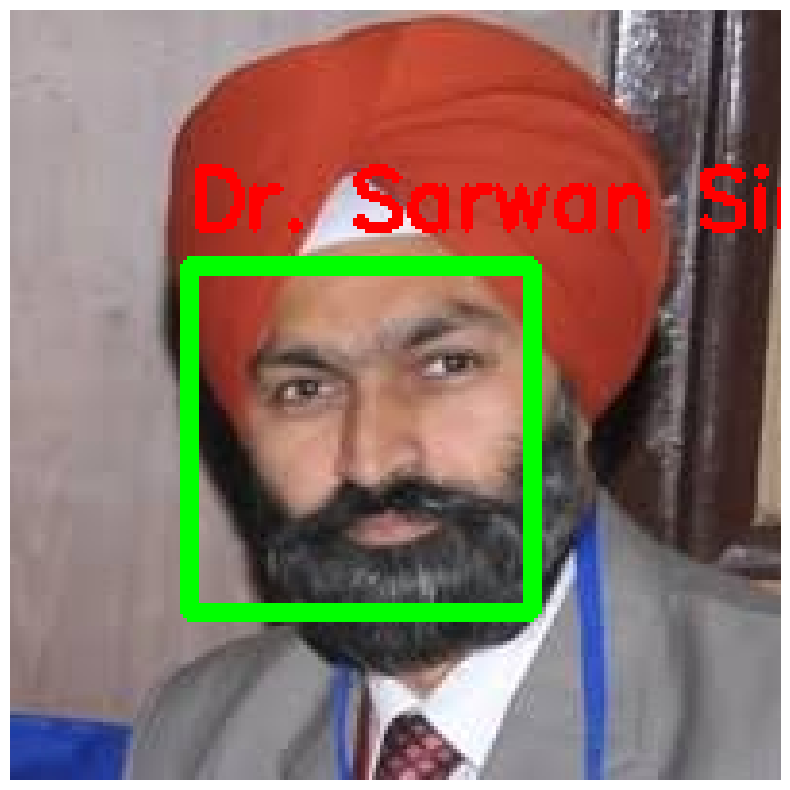

In [ ]:
THRESHOLD = 0.5

attendance_image = face_recognition.load_image_file(
    attendance_image_path
)

face_locations = face_recognition.face_locations(
    attendance_image
)

face_encodings = face_recognition.face_encodings(
    attendance_image,
    face_locations
)

output_image = attendance_image.copy()

print("Faces Detected:", len(face_locations))

for (top, right, bottom, left), face_encoding in zip(
    face_locations,
    face_encodings
):

    matches = face_recognition.compare_faces(
        known_encodings,
        face_encoding,
        tolerance=THRESHOLD
    )

    distances = face_recognition.face_distance(
        known_encodings,
        face_encoding
    )

    name = "Unknown"
    confidence = 0

    if len(distances) > 0:

        best_match_index = np.argmin(distances)

        confidence = round(
            (1 - distances[best_match_index]) * 100,
            2
        )

        if matches[best_match_index]:
            name = known_names[best_match_index]

            mark_attendance(name, confidence)

    cv2.rectangle(
        output_image,
        (left, top),
        (right, bottom),
        (0, 255, 0),
        3
    )

    label = f"{name} | {confidence}%"

    cv2.putText(
        output_image,
        label,
        (left, top - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(14, 10))
plt.imshow(output_image)
plt.axis("off")
plt.show()


# View Attendance Sheet


In [ ]:
attendance_df = pd.read_csv(ATTENDANCE_FILE)

attendance_df

,Name,Confidence,Date,Time
0,Dr. Sarwan Singh,59.96,2026-05-12,01:09:01



# Download Attendance CSV


In [ ]:
files.download(ATTENDANCE_FILE)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# Best Practices

- Use clear frontal face images
- Capture 3–5 images per person
- Maintain proper lighting
- Avoid blurry images
- Use threshold between 0.4–0.6
- Store attendance securely



# Exercises

1. Add live webcam loop
2. Save face snapshots automatically
3. Add DeepFace emotion analysis
4. Build Flask web app
5. Add SQLite database support



# Congratulations

You built a complete:

- Multi-person face recognition system
- Attendance automation system
- Multi-face recognition workflow
- CSV attendance tracker

This is a solid foundation for production AI attendance systems.
